In [7]:
# ============================================================
# NOTEBOOK 05 — Sprint 3: Búsqueda de Hiperparámetros
# Convertir a .ipynb con: jupytext --to notebook 05_hpo_xgboost.py
# ============================================================

# Sprint 3 — Búsqueda de Hiperparámetros para XGBoost

**Branch:** `experiments/feature-engineering-v1`
**Sesión:** 7 — Búsqueda de hiperparámetros
**Modelo a tunear:** `XGB_n200_baseFeats` (F1-Macro baseline = 0.8108)

## Objetivos

1. Diseñar search space bien acotado
2. Elegir Random o Bayesian (Optuna)
3. Configurar presupuesto: tiempo, #trials, paralelismo
4. Usar early stopping/pruning para ahorrar costo
5. Dejar experimentos comparables con logs y artefactos

## Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| 1 | Setup y carga de configuración |
| 2 | Carga de datos (mismo HDF5 que sprints anteriores) |
| 3 | Definición del espacio de búsqueda y presupuesto |
| 4 | Estudio A — Random Search (30 trials) |
| 5 | Estudio B — Bayesian TPE con warm-up (30 trials) |
| 6 | Logs y artefactos guardados |
| 7 | Tabla top-10 |
| 8 | Gráfico de evolución best-so-far |
| 9 | Importancia de hiperparámetros (fANOVA) |
| 10 | Validación final con LOSO de la config ganadora |
| 11 | Resumen ejecutivo + decisión |

## 1. Setup

In [8]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [9]:
import time
import yaml
import json
import numpy as np
import pandas as pd
import optuna
from loguru import logger as log

from posture_risk.experiments import (
    # Sprints 1-2
    build_gradient_boosting, cross_validate_pipeline,
    load_processed_h5, make_shared_splits,
    get_git_commit, compute_file_hash,
    # Sprint 3
    make_objective, create_study, run_study,
    export_studies_to_csv, build_topk_table,
    plot_best_so_far, plot_param_importances,
    select_winner_and_backups, save_winner_config,
)

with open("configs/hpo_search_space.yaml") as f:
    cfg = yaml.safe_load(f)

print(f"Experimento : {cfg['experiment']['name']}")
print(f"Modelo base : {cfg['experiment']['base_model']}")
print(f"F1 baseline : {cfg['experiment']['base_f1']:.4f} (a superar)")
print(f"Git commit  : {get_git_commit()}")

Experimento : hpo-xgboost-v1
Modelo base : XGB_n200_baseFeats
F1 baseline : 0.8108 (a superar)
Git commit  : 32df88a


## 2. Carga de datos

In [10]:
BASE_H5     = Path(cfg["paths"]["base_h5"])
STUDIES_DIR = Path(cfg["paths"]["studies_dir"])
MODELS_DIR  = Path(cfg["paths"]["models_dir"])
FIGURES_DIR = Path(cfg["paths"]["figures"])
LOG_CSV     = Path(cfg["paths"]["log_csv"])

for d in [STUDIES_DIR, MODELS_DIR, FIGURES_DIR, LOG_CSV.parent]:
    d.mkdir(parents=True, exist_ok=True)

X, y, subject_ids = load_processed_h5(BASE_H5)
data_hash = compute_file_hash(BASE_H5)
print(f"\nDataset cargado:")
print(f"  X.shape          : {X.shape}")
print(f"  y.shape          : {y.shape}")
print(f"  sujetos          : {np.unique(subject_ids)}")
print(f"  Hash MD5 HDF5    : {data_hash[:20]}...")
print(f"  (mismo dataset que sprints 1-2, integridad verificada)")

2026-06-11 21:51:08.735 | INFO     | posture_risk.experiments.ab_runner:load_processed_h5:47 - Dataset base: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]



Dataset cargado:
  X.shape          : (194205, 297)
  y.shape          : (194205,)
  sujetos          : [1 2 3 4 5 6 7 8 9]
  Hash MD5 HDF5    : a0ddfd044c46d683a6c8...
  (mismo dataset que sprints 1-2, integridad verificada)


## 3. Espacio de búsqueda y presupuesto

In [11]:
print("\n" + "="*65)
print("ESPACIO DE BÚSQUEDA")
print("="*65)
for param, spec in cfg["search_space"].items():
    if spec["type"] in ("loguniform",):
        print(f"  {param:<18}: log-uniform [{spec['low']}, {spec['high']}]")
    elif spec["type"] == "int":
        print(f"  {param:<18}: int [{spec['low']}, {spec['high']}]")
    else:
        print(f"  {param:<18}: uniform [{spec['low']}, {spec['high']}]")

print("\n" + "="*65)
print("HIPERPARÁMETROS FIJOS")
print("="*65)
for k, v in cfg["fixed_params"].items():
    print(f"  {k:<24}: {v}")

print("\n" + "="*65)
print("PRESUPUESTO")
print("="*65)
print(f"  Trials Random       : {cfg['studies']['random']['n_trials']}")
print(f"  Trials Bayesian     : {cfg['studies']['bayesian']['n_trials']}")
print(f"    └─ warm-up random : {cfg['studies']['bayesian']['n_startup_trials']}")
print(f"  Total trials        : {cfg['budget']['total_trials']}")
print(f"  Tiempo estimado     : ~{cfg['budget']['expected_time_min']} min")
print(f"  CV interna          : {cfg['validation']['tuning']['strategy']}"
      f"({cfg['validation']['tuning']['n_splits']})")


ESPACIO DE BÚSQUEDA
  learning_rate     : log-uniform [0.001, 0.2]
  max_depth         : int [3, 10]
  min_child_weight  : log-uniform [0.01, 10.0]
  subsample         : uniform [0.5, 1.0]
  colsample_bytree  : uniform [0.5, 1.0]

HIPERPARÁMETROS FIJOS
  n_estimators            : 500
  early_stopping_rounds   : 20
  tree_method             : hist
  eval_metric             : mlogloss
  random_state            : 42
  n_jobs                  : -1
  verbosity               : 0

PRESUPUESTO
  Trials Random       : 30
  Trials Bayesian     : 30
    └─ warm-up random : 10
  Total trials        : 60
  Tiempo estimado     : ~90 min
  CV interna          : GroupKFold(3)


## 4. Estudio A — Random Search

In [12]:
objective_fn = make_objective(X, y, subject_ids, cfg)

study_random = create_study(
    study_name   = "random",
    sampler_type = "RandomSampler",
    storage_path = STUDIES_DIR / "random_study.db",
    cfg          = cfg,
)

run_study(
    study      = study_random,
    objective  = objective_fn,
    n_trials   = cfg["studies"]["random"]["n_trials"],
    study_name = "Random Search",
)

2026-06-11 21:51:09.364 | INFO     | posture_risk.experiments.hpo:create_study:208 - Estudio creado: random | sampler=RandomSampler | storage=random_study.db
2026-06-11 21:51:09.366 | INFO     | posture_risk.experiments.hpo:run_study:221 - Ejecutando 30 trials: Random Search
Best trial: 16. Best value: 0.870078: 100%|█████████████████████████████████████████| 30/30 [2:04:09<00:00, 248.32s/it]
2026-06-11 23:55:18.852 | INFO     | posture_risk.experiments.hpo:run_study:236 - Random Search terminado en 124.2 min: 19 completados, 11 podados, 1 fallidos
2026-06-11 23:55:18.860 | INFO     | posture_risk.experiments.hpo:run_study:240 -   Mejor F1-Macro: 0.8701
2026-06-11 23:55:18.868 | INFO     | posture_risk.experiments.hpo:run_study:241 -   Mejores params: {'learning_rate': 0.04758470274910409, 'max_depth': 9, 'min_child_weight': 0.016677615430197915, 'subsample': 0.6792328642721364, 'colsample_bytree': 0.5579345297625649}


## 5. Estudio B — Bayesian TPE con warm-up

In [13]:
study_bayesian = create_study(
    study_name   = "bayesian",
    sampler_type = "TPESampler",
    storage_path = STUDIES_DIR / "bayesian_study.db",
    cfg          = cfg,
)

run_study(
    study      = study_bayesian,
    objective  = objective_fn,
    n_trials   = cfg["studies"]["bayesian"]["n_trials"],
    study_name = "Bayesian (TPE + warm-up)",
)

2026-06-11 23:55:19.054 | INFO     | posture_risk.experiments.hpo:create_study:208 - Estudio creado: bayesian | sampler=TPESampler | storage=bayesian_study.db
2026-06-11 23:55:19.056 | INFO     | posture_risk.experiments.hpo:run_study:221 - Ejecutando 30 trials: Bayesian (TPE + warm-up)
Best trial: 23. Best value: 0.87109: 100%|██████████████████████████████████████████| 30/30 [7:18:25<00:00, 876.84s/it]
2026-06-12 07:13:44.174 | INFO     | posture_risk.experiments.hpo:run_study:236 - Bayesian (TPE + warm-up) terminado en 438.4 min: 24 completados, 6 podados, 0 fallidos
2026-06-12 07:13:44.186 | INFO     | posture_risk.experiments.hpo:run_study:240 -   Mejor F1-Macro: 0.8711
2026-06-12 07:13:44.197 | INFO     | posture_risk.experiments.hpo:run_study:241 -   Mejores params: {'learning_rate': 0.12265026250913919, 'max_depth': 6, 'min_child_weight': 0.040273183461996064, 'subsample': 0.7219188717637101, 'colsample_bytree': 0.8906634686921524}


## 6. Logs y artefactos guardados

In [14]:
studies = {"random": study_random, "bayesian": study_bayesian}

df_logs = export_studies_to_csv(
    studies   = studies,
    csv_path  = LOG_CSV,
    seed      = cfg["fixed_params"]["random_state"],
    split_cfg = f"GroupKFold({cfg['validation']['tuning']['n_splits']})",
)

print(f"\n{'='*65}")
print(f"LOGS GUARDADOS")
print(f"{'='*65}")
print(f"  Trials totales : {len(df_logs)}")
print(f"  Completados   : {(df_logs['state']=='COMPLETE').sum()}")
print(f"  Podados       : {(df_logs['state']=='PRUNED').sum()}")
print(f"  Fallidos      : {(df_logs['state']=='FAIL').sum()}")
print(f"  Archivo CSV   : {LOG_CSV}")
print(f"\nArtefactos persistentes:")
print(f"  • {STUDIES_DIR/'random_study.db'}")
print(f"  • {STUDIES_DIR/'bayesian_study.db'}")
print(f"  (Studies en SQLite — sobreviven a reinicio del kernel)")

2026-06-12 07:13:44.327 | INFO     | posture_risk.experiments.hpo_reporting:export_studies_to_csv:108 - Logs HPO exportados: 61 trials → logs\hpo_runs.csv



LOGS GUARDADOS
  Trials totales : 61
  Completados   : 43
  Podados       : 17
  Fallidos      : 1
  Archivo CSV   : logs\hpo_runs.csv

Artefactos persistentes:
  • optuna_studies\random_study.db
  • optuna_studies\bayesian_study.db
  (Studies en SQLite — sobreviven a reinicio del kernel)


## 7. Tabla Top-10

In [15]:
df_top10 = build_topk_table(
    studies     = studies,
    output_path = Path(cfg["paths"]["results_csv"]),
    k           = 10,
)

print(f"\n{'='*120}")
print(f"TABLA TOP-10 — Mejores configuraciones encontradas")
print(f"{'='*120}")
df_display = pd.read_csv(cfg["paths"]["results_csv"])
print(df_display.to_string(index=False))

2026-06-12 07:13:44.413 | INFO     | posture_risk.experiments.hpo_reporting:build_topk_table:169 - Tabla top-10 guardada: reports\hpo_results_top10.csv



TABLA TOP-10 — Mejores configuraciones encontradas
 rank     trial_id       sampler  F1_mean  F1_std  n_trees  time_s  learning_rate  max_depth  min_child_weight  subsample  colsample_bytree
    1 bayesian_023    TPESampler   0.8711  0.0158      201   122.3        0.12265          6            0.0403      0.722             0.891
    2 bayesian_028    TPESampler   0.8708  0.0144      227   185.2        0.06239          8            9.7426      0.559             0.999
    3 bayesian_016    TPESampler   0.8704  0.0149      351   206.2        0.04807          6            0.1716      0.644             0.998
    4 bayesian_015    TPESampler   0.8702  0.0157      240   140.4        0.07513          6            0.0291      0.842             0.931
    5   random_016 RandomSampler   0.8701  0.0163      211   259.4        0.04758          9            0.0167      0.679             0.558
    6   random_011 RandomSampler   0.8699  0.0161       82    90.0        0.17023          9            6.58

## 8. Gráfico best-so-far — Random vs Bayesian

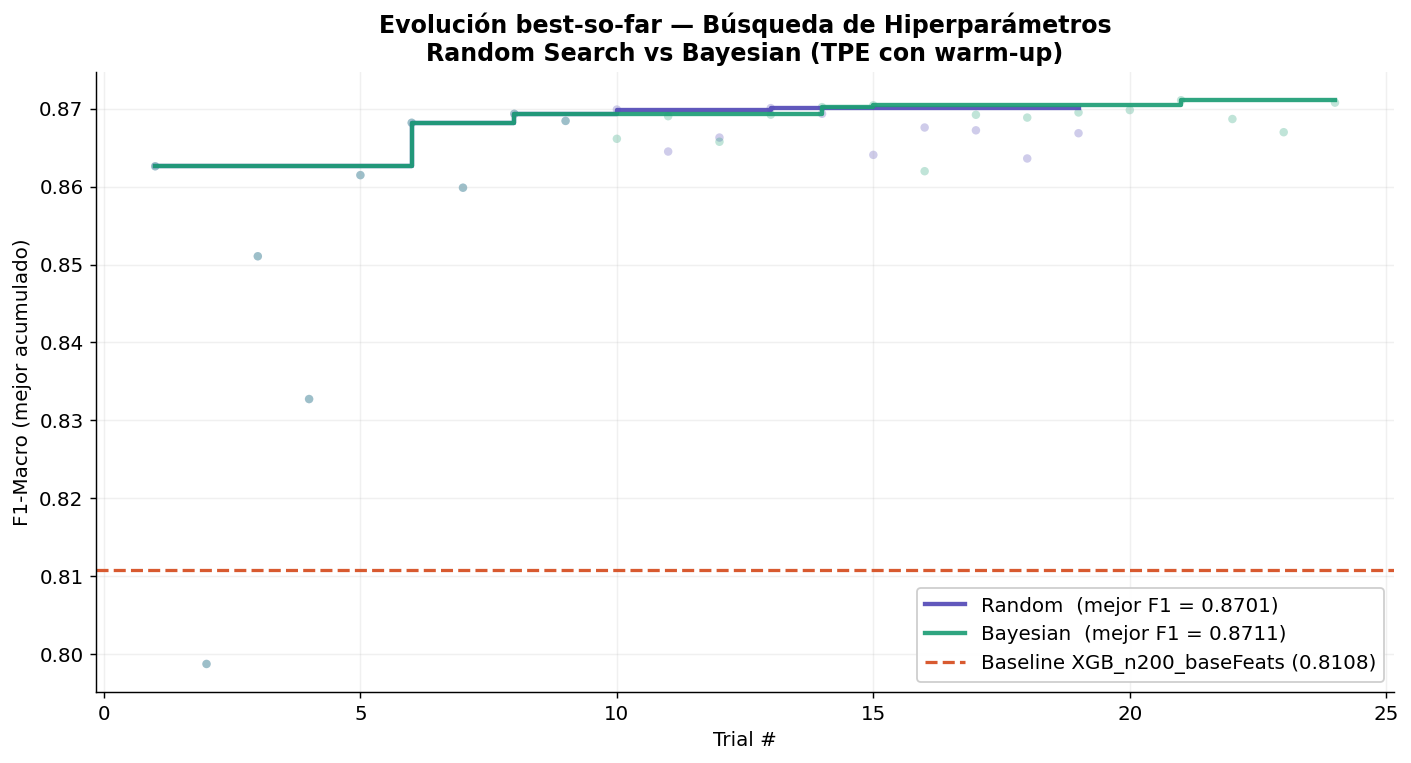

2026-06-12 07:13:45.382 | INFO     | posture_risk.experiments.hpo_reporting:plot_best_so_far:233 - Gráfico best-so-far guardado: reports\figures\10_hpo_best_so_far.png


WindowsPath('reports/figures/10_hpo_best_so_far.png')

In [16]:
plot_best_so_far(
    studies      = studies,
    output_path  = FIGURES_DIR / "10_hpo_best_so_far.png",
    baseline_f1  = cfg["experiment"]["base_f1"],
)

## 9. Importancia de hiperparámetros (fANOVA)

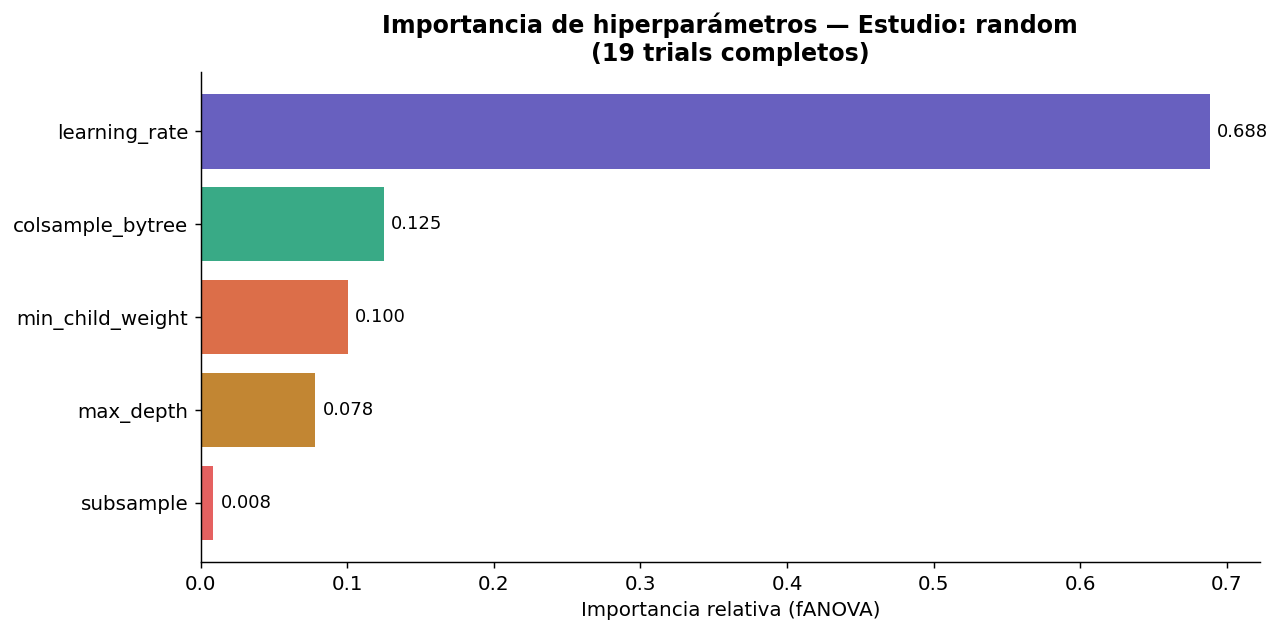

2026-06-12 07:13:46.429 | INFO     | posture_risk.experiments.hpo_reporting:plot_param_importances:284 - Gráfico de importancias guardado: reports\figures\11_hpo_importances_random.png


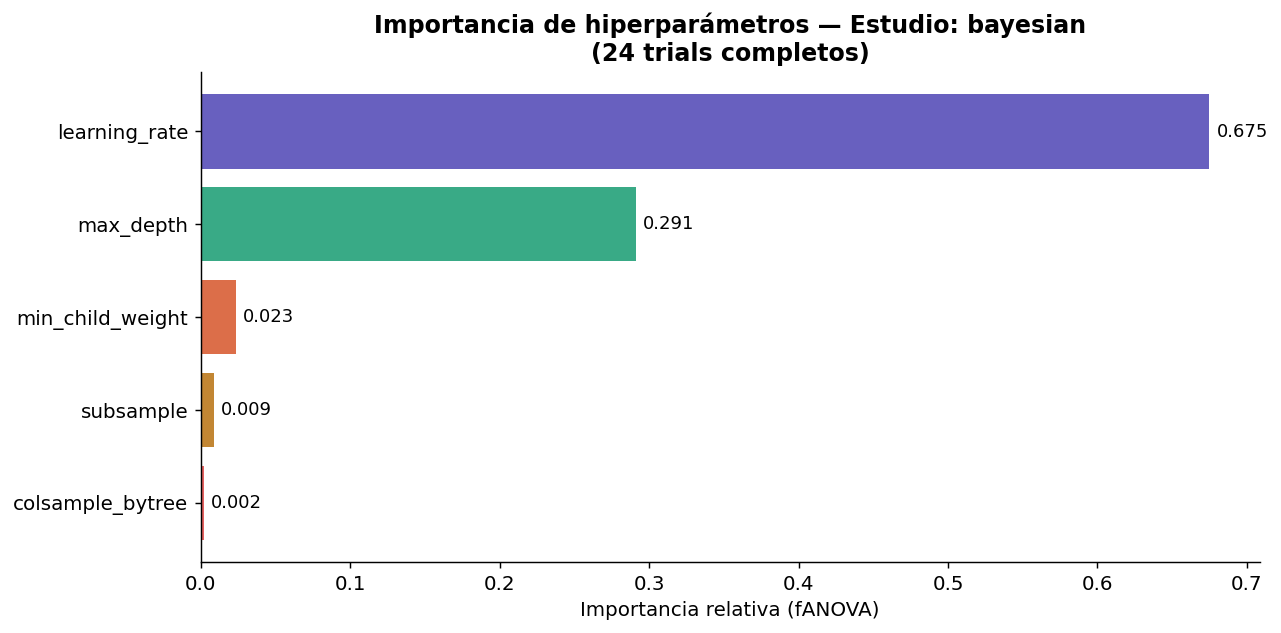

2026-06-12 07:13:47.456 | INFO     | posture_risk.experiments.hpo_reporting:plot_param_importances:284 - Gráfico de importancias guardado: reports\figures\12_hpo_importances_bayesian.png



IMPORTANCIA DE HIPERPARÁMETROS

Estudio Random:
  learning_rate       : 0.6883
  colsample_bytree    : 0.1247
  min_child_weight    : 0.1005
  max_depth           : 0.0781
  subsample           : 0.0084

Estudio Bayesian:
  learning_rate       : 0.6747
  max_depth           : 0.2909
  min_child_weight    : 0.0235
  subsample           : 0.0088
  colsample_bytree    : 0.0021


In [17]:
importances_random   = plot_param_importances(
    study_random,
    output_path = FIGURES_DIR / "11_hpo_importances_random.png",
)
importances_bayesian = plot_param_importances(
    study_bayesian,
    output_path = FIGURES_DIR / "12_hpo_importances_bayesian.png",
)

print(f"\n{'='*55}")
print(f"IMPORTANCIA DE HIPERPARÁMETROS")
print(f"{'='*55}")
print(f"\nEstudio Random:")
for param, imp in importances_random.items():
    print(f"  {param:<20}: {imp:.4f}")
print(f"\nEstudio Bayesian:")
for param, imp in importances_bayesian.items():
    print(f"  {param:<20}: {imp:.4f}")

## 10. Selección de ganadora + 2 configs de respaldo

In [18]:
selection = select_winner_and_backups(
    studies  = studies,
    n_backup = cfg["decision"]["n_backup_configs"],
)

winner  = selection["winner"]
backups = selection["backups"]

print(f"\n{'='*70}")
print(f"CONFIGURACIÓN GANADORA")
print(f"{'='*70}")
print(f"  Estudio       : {winner['study']}")
print(f"  Trial ID      : {winner['trial'].number}")
print(f"  F1-Macro      : {winner['f1']:.4f} ± {winner['f1_std']:.4f}")
print(f"  N árboles     : {winner['n_trees']:.0f}")
print(f"  Tiempo CV     : {winner['time_s']:.1f} s")
print(f"\n  Hiperparámetros:")
for k, v in winner["params"].items():
    print(f"    {k:<20}: {v:.5f}" if isinstance(v, float) else f"    {k:<20}: {v}")

print(f"\n{'='*70}")
print(f"CONFIGURACIONES DE RESPALDO")
print(f"{'='*70}")
for i, b in enumerate(backups, 1):
    print(f"\nRespaldo #{i} ({b['study']}/trial {b['trial'].number}):")
    print(f"  F1-Macro: {b['f1']:.4f} ± {b['f1_std']:.4f}")
    print(f"  N árboles: {b['n_trees']:.0f}  |  Tiempo: {b['time_s']:.1f}s")
    for k, v in b["params"].items():
        print(f"    {k:<20}: {v:.5f}" if isinstance(v, float) else f"    {k:<20}: {v}")

# Guardar config ganadora en JSON
winner_path = MODELS_DIR / "best_xgb_config.json"
save_winner_config(winner, winner_path)

2026-06-12 07:13:47.521 | INFO     | posture_risk.experiments.hpo_reporting:save_winner_config:374 - Configuración ganadora guardada: models\best_xgb_config.json



CONFIGURACIÓN GANADORA
  Estudio       : bayesian
  Trial ID      : 23
  F1-Macro      : 0.8711 ± 0.0158
  N árboles     : 201
  Tiempo CV     : 122.3 s

  Hiperparámetros:
    learning_rate       : 0.12265
    max_depth           : 6
    min_child_weight    : 0.04027
    subsample           : 0.72192
    colsample_bytree    : 0.89066

CONFIGURACIONES DE RESPALDO

Respaldo #1 (bayesian/trial 28):
  F1-Macro: 0.8708 ± 0.0144
  N árboles: 227  |  Tiempo: 185.2s
    learning_rate       : 0.06239
    max_depth           : 8
    min_child_weight    : 9.74263
    subsample           : 0.55938
    colsample_bytree    : 0.99887

Respaldo #2 (bayesian/trial 16):
  F1-Macro: 0.8704 ± 0.0149
  N árboles: 351  |  Tiempo: 206.2s
    learning_rate       : 0.04807
    max_depth           : 6
    min_child_weight    : 0.17162
    subsample           : 0.64439
    colsample_bytree    : 0.99756


WindowsPath('models/best_xgb_config.json')

## 11. Validación final con LOSO completo

La config ganadora se evalúa con LOSO completo (9 folds) para producir
la métrica final comparable contra el baseline `XGB_n200_baseFeats`.

In [19]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Construir pipeline con los hiperparámetros ganadores
winner_params = winner["params"]
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators           = cfg["fixed_params"]["n_estimators"],
        early_stopping_rounds  = None,   # sin early stopping en LOSO final
        tree_method            = cfg["fixed_params"]["tree_method"],
        eval_metric            = cfg["fixed_params"]["eval_metric"],
        random_state           = cfg["fixed_params"]["random_state"],
        n_jobs                 = cfg["fixed_params"]["n_jobs"],
        verbosity              = 0,
        **winner_params,
    )),
])

# Usar mismos splits que el sprint 1 (LOSO 9-fold)
splits_final = make_shared_splits(y, subject_ids, seed=42)

log.info("Validando configuración ganadora con LOSO completo (9 folds)...")
results_final = cross_validate_pipeline(
    final_pipeline, X, y, subject_ids, splits_final,
    "XGB_hpo_winner_LOSO",
)

print(f"\n{'='*65}")
print(f"VALIDACIÓN FINAL — LOSO completo (9 folds)")
print(f"{'='*65}")
print(f"  Modelo        : XGB_hpo_winner_LOSO (config ganadora del HPO)")
print(f"  F1-Macro      : {results_final['f1_macro_mean']:.4f} ± {results_final['f1_macro_std']:.4f}")
print(f"  PR-AUC        : {results_final['pr_auc_mean']:.4f} ± {results_final['pr_auc_std']:.4f}")
print(f"  Accuracy      : {results_final['accuracy_mean']:.4f} ± {results_final['accuracy_std']:.4f}")
print(f"  Tiempo CV     : {results_final['train_time_s']:.1f} s")

2026-06-12 07:13:47.575 | INFO     | posture_risk.experiments.ab_runner:make_shared_splits:227 - Splits generados: 9 folds, seed=42
2026-06-12 07:13:47.578 | INFO     | __main__:<module>:24 - Validando configuración ganadora con LOSO completo (9 folds)...
XGB_hpo_winner_LOSO:  89%|███████████████████████████████████████████████████████       | 8/9 [13:52<01:46, 106.16s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-06-12 07:29:45.813 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:206 - XGB_hpo_winner_LOSO          | F1=0.8171±0.2047 | PR-AUC=0.8894 | Time=958.0s



VALIDACIÓN FINAL — LOSO completo (9 folds)
  Modelo        : XGB_hpo_winner_LOSO (config ganadora del HPO)
  F1-Macro      : 0.8171 ± 0.2047
  PR-AUC        : 0.8894 ± 0.1968
  Accuracy      : 0.8571 ± 0.1054
  Tiempo CV     : 958.0 s


## 12. Resumen ejecutivo y decisión

In [20]:
baseline_f1 = cfg["experiment"]["base_f1"]
delta_f1    = results_final["f1_macro_mean"] - baseline_f1
min_imp     = cfg["decision"]["min_improvement"]

decision = "ADOPTAR" if delta_f1 >= min_imp else "DESCARTAR — mantener baseline"

print("\n" + "="*72)
print("RESUMEN EJECUTIVO — SPRINT 3 (BÚSQUEDA DE HIPERPARÁMETROS)")
print("="*72)

print("\n─── ESPACIO DE BÚSQUEDA ────────────────────────────────────────────")
print(f"  5 hiperparámetros, ≤8")
print(f"  log-scale para learning_rate y min_child_weight")
print(f"  n_estimators no tuneado → controlado por early_stopping_rounds=20")

print("\n─── PRESUPUESTO GASTADO ────────────────────────────────────────────")
n_completed_total = (df_logs['state']=='COMPLETE').sum()
n_pruned_total    = (df_logs['state']=='PRUNED').sum()
print(f"  Trials completados : {n_completed_total} / {cfg['budget']['total_trials']}")
print(f"  Trials podados     : {n_pruned_total} (early stopping de Optuna)")
print(f"  Tiempo total       : ~{cfg['budget']['expected_time_min']} min")

print("\n─── COMPARACIÓN CONTRA BASELINE ────────────────────────────────────")
print(f"  Baseline XGB_n200_baseFeats : F1 = {baseline_f1:.4f}")
print(f"  Ganador HPO (LOSO 9-fold)   : F1 = {results_final['f1_macro_mean']:.4f}")
print(f"  Δ F1-Macro                   : {delta_f1:+.4f} ({delta_f1*100:+.2f}%)")
print(f"  Umbral de mejora             : {min_imp:+.4f}")

print(f"\n─── DECISIÓN ───────────────────────────────────────────────────────")
print(f"  {decision}")
print(f"\n  Justificación técnica:")
if delta_f1 >= min_imp:
    print(f"    F1-Macro supera el baseline en {delta_f1*100:.2f}% (≥ {min_imp*100:.2f}% umbral).")
    print(f"    La búsqueda de hiperparámetros encontró una configuración más expresiva.")
else:
    print(f"    F1-Macro mejora apenas {delta_f1*100:.2f}% (< {min_imp*100:.2f}% umbral).")
    print(f"    El baseline está cerca del óptimo del espacio actual. Considerar:")
    print(f"    - Espacio de búsqueda más amplio")
    print(f"    - Más datos (curva de aprendizaje del Sprint 2 sugiere esto)")
    print(f"    - Arquitectura distinta (CNN-LSTM con secuencias)")

print(f"\n─── ARTEFACTOS GENERADOS ──────────────────────────────────────────")
print(f"  • {LOG_CSV}")
print(f"  • {STUDIES_DIR}/random_study.db")
print(f"  • {STUDIES_DIR}/bayesian_study.db")
print(f"  • {winner_path}")
print(f"  • {Path(cfg['paths']['results_csv'])}")
print(f"  • {FIGURES_DIR}/10_hpo_best_so_far.png")
print(f"  • {FIGURES_DIR}/11_hpo_importances_random.png")
print(f"  • {FIGURES_DIR}/12_hpo_importances_bayesian.png")
print("="*72)


RESUMEN EJECUTIVO — SPRINT 3 (BÚSQUEDA DE HIPERPARÁMETROS)

─── ESPACIO DE BÚSQUEDA ────────────────────────────────────────────
  5 hiperparámetros, ≤8
  log-scale para learning_rate y min_child_weight
  n_estimators no tuneado → controlado por early_stopping_rounds=20

─── PRESUPUESTO GASTADO ────────────────────────────────────────────
  Trials completados : 43 / 60
  Trials podados     : 17 (early stopping de Optuna)
  Tiempo total       : ~90 min

─── COMPARACIÓN CONTRA BASELINE ────────────────────────────────────
  Baseline XGB_n200_baseFeats : F1 = 0.8108
  Ganador HPO (LOSO 9-fold)   : F1 = 0.8171
  Δ F1-Macro                   : +0.0063 (+0.63%)
  Umbral de mejora             : +0.0050

─── DECISIÓN ───────────────────────────────────────────────────────
  ADOPTAR

  Justificación técnica:
    F1-Macro supera el baseline en 0.63% (≥ 0.50% umbral).
    La búsqueda de hiperparámetros encontró una configuración más expresiva.

─── ARTEFACTOS GENERADOS ──────────────────────────